# DAS data loader and analyser
This notebook provides a demonstration on loading and analysising DAS data

In [3]:
# Import required libraries
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta,timezone
import glob
import os
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from scipy.signal import butter, filtfilt, firwin
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import tukey
from scipy.interpolate import interp1d
# from matplotlib.colors import LinearSegmentedColomap
from matplotlib.ticker import AutoMinorLocator

# Set up matplotlib for inline plotting
%matplotlib inline

dmin_km = 0
dmax_km = 50

The below cell contains all the functions required for viewing and processing the DAS data

In [6]:
def extract_metadata(file_path):
    """Extract metadata from HDF5 file"""
    with h5py.File(file_path, "r") as hdf5_file:
        start_time = hdf5_file["header/time"][()]
        dt = hdf5_file["header/dt"][()]
        dx = hdf5_file["header/dx"][()]
        channels = hdf5_file["header/channels"][()]
        # Get the actual number of samples in the file
        num_samples = hdf5_file["data"].shape[0]
    return start_time, dt, dx, channels, num_samples

def fir_bandpass(data, lowcut, highcut, fs, numtaps=101):
    """FIR bandpass filter with Nyquist frequency check"""
    nyquist = 0.5 * fs
    if highcut >= nyquist:
        highcut = nyquist * 0.99
    taps = firwin(numtaps, [lowcut/nyquist, highcut/nyquist], pass_zero=False)
    return filtfilt(taps, [1.0], data, axis=-1)


def find_start_file(file_paths, start_time_str):
    """Find the first file at or after the specified start time (HHMMSS format)"""
    # Convert input time string to datetime.time object
    try:
        input_time = datetime.strptime(start_time_str, "%H%M%S").time()
    except ValueError:
        raise ValueError("Invalid time format. Please use HHMMSS format (e.g., 102030)")

    # Find all files that match the time pattern
    time_files = []
    for file_path in file_paths:
        filename = os.path.basename(file_path)
        if filename.endswith('.hdf5'):
            time_str = filename.split('.')[0]
            try:
                file_time = datetime.strptime(time_str, "%H%M%S").time()
                time_files.append((file_time, file_path))
            except ValueError:
                continue

    if not time_files:
        raise ValueError("No valid time-based HDF5 files found in the directory")

    # Sort files by time
    time_files.sort()

    # Find the first file at or after the requested time
    for file_time, file_path in time_files:
        if file_time >= input_time:
            return file_path, time_files.index((file_time, file_path))

    # If we get here, all files are before requested time - return last file
    return time_files[-1][1], len(time_files) - 1

def compute_spectrogram(signal, fs, Nfft=2048, overlap=0.9, file_time=None):
    """Compute spectrogram using matplotlib's specgram function"""
    Nover = int(np.floor(Nfft * overlap))
    pspect, fspect, tspect = plt.mlab.specgram(
        signal,
        NFFT=Nfft,
        Fs=fs,
        window=np.hanning(Nfft),
        noverlap=Nover,
        mode="psd",
    )
    psd = 10 * np.log10(pspect)
    if file_time:
        tspect_utc = [datetime.fromtimestamp(file_time) + timedelta(seconds=t) for t in tspect]
    else:
        tspect_utc = tspect
    return np.array(tspect_utc), fspect, psd

def load_and_join_data(input_directory, channel_step, start_time=None, end_time=None):
    """
    Load and concatenate data from HDF5 files within a specified time range.

    Parameters
    ----------
    input_directory : str
        Folder containing the HDF5 DAS files.
    channel_step : int
        Spatial downsampling factor.
    start_time, end_time : str, optional
        Start and end times in HHMMSS format. If None, load all available data.

    Returns
    -------
    data : np.ndarray
        Concatenated DAS data.
    time_axis : list
        List of datetime objects for the time axis.
    dt : float
        Sampling interval.
    dx : float
        Spatial sampling interval.
    channels_array : np.ndarray
        Array of channel indices.
    """
    file_paths = sorted(glob.glob(os.path.join(input_directory, '*.hdf5')))

    if not file_paths:
        raise FileNotFoundError(f"No HDF5 files found in {input_directory}")

    # Find the start and end files based on the time window
    start_file_path = file_paths[0]
    end_file_path = file_paths[-1]
    start_file_index = 0
    end_file_index = len(file_paths) - 1

    if start_time:
        try:
            start_file_path, start_file_index = find_start_file(file_paths, start_time)
        except ValueError as e:
            print(f"Warning: Could not find start file for time {start_time}. Loading from the first file. Error: {e}")

    if end_time:
         # For the end time, we need to find files up to and including the one that contains the end time.
         # We can reuse find_start_file but logic needs adjustment to find the last file *before* the end time + 1 file.
         # A simpler approach for now is to iterate from the start file and stop when we pass the end time.
         try:
            end_datetime = datetime.strptime(end_time, "%H%M%S").time()
            temp_end_index = start_file_index
            for i in range(start_file_index, len(file_paths)):
                 filename = os.path.basename(file_paths[i])
                 if filename.endswith('.hdf5'):
                    time_str = filename.split('.')[0]
                    try:
                         file_time = datetime.strptime(time_str, "%H%M%S").time()
                         if file_time <= end_datetime:
                             temp_end_index = i
                         else:
                             break # Stop when we pass the end time
                    except ValueError:
                         continue
            end_file_index = temp_end_index

         except ValueError as e:
             print(f"Warning: Could not parse end time {end_time}. Loading up to the last file. Error: {e}")


    # Ensure end_file_index is not before start_file_index
    end_file_index = max(start_file_index, end_file_index)


    selected_file_paths = file_paths[start_file_index : end_file_index + 1]

    if not selected_file_paths:
        raise ValueError("No files selected based on the provided time window.")

    # Extract metadata from the first selected file
    file_start_time_unix, dt, dx, channels_array, _ = extract_metadata(selected_file_paths[0])

    all_data = []
    time_axis = []
    total_samples = 0

    for file_path in selected_file_paths:
        try:
            current_start_time_unix, current_dt, _, current_channels_array, current_num_samples = extract_metadata(file_path)
            if current_dt != dt:
                print(f"Warning: dt mismatch in {file_path}. Expected {dt}, got {current_dt}. Skipping file.")
                continue
            if not np.array_equal(current_channels_array, channels_array):
                 print(f"Warning: Channel mismatch in {file_path}. Skipping file.")
                 continue


            with h5py.File(file_path, 'r') as f:
                # Load all channels for the current file
                file_data = f['data'][:]

                # Downsample channels
                file_data_downsampled = file_data[:, ::channel_step]


                # Create time axis for this file
                file_start_datetime = datetime.utcfromtimestamp(current_start_time_unix)
                # Calculate times for each sample in the current file
                file_times_seconds = np.arange(current_num_samples) * current_dt
                file_times_datetime = [file_start_datetime + timedelta(seconds=float(t)) for t in file_times_seconds]

                all_data.append(file_data_downsampled)
                time_axis.extend(file_times_datetime)
                total_samples += file_data_downsampled.shape[0]

        except KeyError as e:
            print(f"Skipping file {file_path} due to error: {e}")
        except Exception as e:
            print(f"Skipping file {file_path} due to unexpected error: {e}")


    if not all_data:
        raise ValueError("No data could be loaded from the selected files.")

    # Concatenate data from all files
    data = np.concatenate(all_data, axis=0)


    return data, time_axis, dt, dx, channels_array[::channel_step]


# @title
# ==========================
#   F-K ANALYSIS IMPLEMENTATION (no filtering, fast log-y support)
# ==========================

def fk_analysis(input_directory,
                dmin_fk, dmax_fk,
                tmin_fk, tmax_fk,
                channel_step,
                fmax_fk,
                velocity_lines,
                log_freq=False,
                n_log_bins=800):
    """
    Perform F-K analysis (no filtering) and plot the spectrum.

    Parameters
    ----------
    input_directory : str
        Folder containing the HDF5 DAS files.
    dmin_fk, dmax_fk : float
        Cable section in km.
    tmin_fk, tmax_fk : str
        Time window in HHMMSS format.
    channel_step : int
        Spatial downsampling factor.
    fmax_fk : float
        Maximum frequency to display.
    velocity_lines : list
        Velocities in m/s to plot lines.
    log_freq : bool
        If True, resample frequencies to logarithmic spacing (faster log-y plotting).
    n_log_bins : int
        Number of bins for log frequency spacing.
    """
    # --- Load data ---
    data, time_axis, dt, dx, channels_array = load_and_join_data(
        input_directory, channel_step=channel_step,
        start_time=tmin_fk, end_time=tmax_fk
    )
    data = data.astype(np.float64)

    # --- Select cable section ---
    distances = channels_array * dx / 1000  # km
    dist_mask = (distances >= dmin_fk) & (distances <= dmax_fk)
    data_section = data[:, dist_mask]
    channels_section = channels_array[dist_mask]
    distances_section = distances[dist_mask]

    if data_section.shape[1] < 2:
        raise ValueError("Not enough channels in the selected cable section for F-K analysis!")

    # --- Remove mean ---
    #data_section -= np.mean(data_section, axis=0, keepdims=True)
    #data_section -= np.mean(data_section, axis=1, keepdims=True)
    #data_section -= np.median(data_section, axis=1, keepdims=True)
    #data_section -= np.mean(data_section, axis=1, keepdims=True)
    data_section -= np.median(data_section, axis=(0, 1), keepdims=True)

    # --- No bandpass filtering ---
    data_filtered = data_section

    # --- 2D Tukey window ---
    nt, nx = data_filtered.shape
    window_2d = tukey(nt, 0.2)[:, None] * tukey(nx, 0.2)[None, :]
    data_windowed = data_filtered * window_2d

    # --- Effective channel spacing ---
    dx_eff = (distances_section[1] - distances_section[0]) * 1000  # m

    # --- 2D FFT and power spectrum ---
    fk = np.fft.fftshift(np.fft.fft2(data_windowed))
    fk_power = np.abs(fk)**2 + 1e-12
    fk_db = 10*np.log10(fk_power)
    fk_db -= np.max(fk_db)

    # --- Frequency and wavenumber axes ---
    freqs = np.fft.fftshift(np.fft.fftfreq(nt, dt))
    k_vals = np.fft.fftshift(np.fft.fftfreq(nx, dx_eff))

    # --- Positive frequencies only ---
    pos_mask = freqs >= 0
    freqs_pos = freqs[pos_mask]
    fk_db_pos = fk_db[pos_mask, :]

    # --- Limit frequency range ---
    freq_mask = freqs_pos <= fmax_fk
    freqs_plot = freqs_pos[freq_mask]
    fk_plot = fk_db_pos[freq_mask, :]

    # --- Log frequency resampling ---
    if log_freq:
        f_start = max(freqs_plot[1], 1e-3)
        log_freqs = np.logspace(np.log10(f_start), np.log10(freqs_plot[-1]), n_log_bins)
        fk_log = np.zeros((len(log_freqs), fk_plot.shape[1]))
        for i in range(fk_plot.shape[1]):
            f_interp = interp1d(freqs_plot, fk_plot[:, i], bounds_error=False, fill_value=np.nan)
            fk_log[:, i] = f_interp(log_freqs)
        freqs_plot = log_freqs
        fk_plot = fk_log

    # --- Ensure all finite for plotting ---
    fk_plot = np.nan_to_num(fk_plot, nan=np.nanmin(fk_plot))

    # --- Adaptive color scale ---
    vmin_db = np.percentile(fk_plot, 5)
    vmax_db = np.percentile(fk_plot, 99)

    # --- Plot F-K ---
    plt.figure(figsize=(12, 8))
    im = plt.pcolormesh(k_vals, freqs_plot, fk_plot,
                        shading='gouraud', cmap='jet',
                        vmin=vmin_db, vmax=vmax_db)
    plt.colorbar(im, label='Power [dB]')
    plt.xlabel("Wavenumber [1/m]")
    plt.ylabel("Frequency [Hz]")
    plt.title(f"F-K Spectrum | Distance {dmin_fk}-{dmax_fk} km | Time {tmin_fk}-{tmax_fk}")
    plt.xlim(-0.04, 0.04)
    plt.ylim(0.001, fmax_fk)
    if log_freq:
        plt.yscale('log')

    # --- Velocity lines (same color ±) ---
    k_max = np.max(np.abs(k_vals))
    colors = plt.cm.tab10(np.linspace(0, 1, len(velocity_lines)))

    for idx, v in enumerate(velocity_lines):
        f_line = np.linspace(freqs_plot[0], freqs_plot[-1], 2000)
        k_line = f_line / v
        k_valid = np.where(np.abs(k_line) <= k_max, k_line, np.nan)
        color = colors[idx]
        plt.plot(k_valid,  f_line, '--', linewidth=1, color=color, label=f'{v} m/s ({np.arccos(1500/v)/np.pi*180:.2f})°')
        plt.plot(-k_valid, f_line, '--', linewidth=1, color=color)

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Diagnostics ---
    print(f"F-K analysis completed:")
    print(f"  Cable section: {dmin_fk}-{dmax_fk} km, Channels: {len(channels_section)}")
    print(f"  Time window: {tmin_fk} - {tmax_fk}, Samples: {nt}")
    print(f"  Frequency range: {freqs_plot[0]:.3f} - {freqs_plot[-1]:.1f} Hz")
    print(f"  Wavenumber range: {k_vals[0]:.4f} - {k_vals[-1]:.4f} 1/m")

In [5]:
# Define the directory containing your HDF5 files
directory= "data/GC_data/20250702"  # Change this to your directory path

# Get all HDF5 files in the directory
file_paths = sorted(glob.glob(os.path.join(directory, '*.hdf5')))
print(len(file_paths))
if not file_paths:
    print(f"No HDF5 files found in {directory}")
else:
    # Extract metadata from the first file
    start_time, dt, dx, channels, num_samples = extract_metadata(file_paths[0])
    fs = 1/dt

    print("Metadata from first file:")
    print(f"Start time (Unix timestamp): {start_time}")
    print(f"Start time (UTC): {datetime.fromtimestamp(start_time, tz=timezone.utc)}")
    print(f"Sampling interval (dt): {dt} seconds")
    print(f"Spatial sampling (dx): {dx} meters")
    print(f"Number of channels: {len(channels)}")
    print(f"Samples per file: {num_samples}")
    print(f"Sampling frequency: {fs} Hz")
    print(f"File duration: {num_samples * dt} seconds")
    print(f"Total files available: {len(file_paths)}")
    print(f"Maximum duration available: {len(file_paths) * num_samples * dt} seconds")

0
No HDF5 files found in data/GC_data/20250702


Based on the parameters provided above decide what data you want to read in.
**Note:** large datasets (e.g. large spatial extend and high sampling rate) might cause a crash as it exceeds the RAM allocation.


A COUPLE OF FILES

In [6]:
# Contiguous 90s window over full distance (downsample channels optionally)
# Adjust these parameters as needed.

# ----- User Parameters -----
desired_duration_seconds = 90        # ~1.5 minutes
start_time_str = None                # e.g. "092535" for HHMMSS start, or None for earliest
channel_step = 10                    # spatial downsampling (1 = all channels)
max_channels = None                  # optional hard cap after downsampling
sample_step = 1                      # temporal downsampling (1 = all samples)
clip_percentile = 99.8               # None to disable amplitude clipping for visualization

file_paths = sorted(glob.glob(os.path.join(directory, '*.hdf5')))
if not file_paths:
    raise FileNotFoundError(f'No HDF5 files found in {directory}')

# Get metadata from first file (assume uniform)
start_time_unix, dt, dx, channels, num_samples_first = extract_metadata(file_paths[0])
file_duration = num_samples_first * dt  # seconds per file
fs = 1.0 / dt

# Determine starting index based on optional time string
if start_time_str:
    try:
        _, start_index = find_start_file(file_paths, start_time_str)
    except Exception as e:
        print(f"Could not locate start time {start_time_str}: {e}. Using first file.")
        start_index = 0
else:
    start_index = 0

# Number of files to span desired duration
import math
n_files_needed = math.ceil(desired_duration_seconds / file_duration)
end_index = min(start_index + n_files_needed, len(file_paths))
selected_files = file_paths[start_index:end_index]

print(f"Total files available: {len(file_paths)}")
print(f"Selected contiguous files: {len(selected_files)} (from index {start_index} to {end_index-1})")
print(f"Each file duration: {file_duration:.2f}s | Target duration: {desired_duration_seconds}s")

# Build distance axis (full span) with downsampling
distance_array_m = channels * dx
distance_array_km = distance_array_m / 1000.0
if channel_step > 1:
    distance_array_km = distance_array_km[::channel_step]
    channels_down = channels[::channel_step]
else:
    channels_down = channels

if max_channels and len(channels_down) > max_channels:
    channels_down = channels_down[:max_channels]
    distance_array_km = distance_array_km[:max_channels]

print(f"Channels after downsampling: {len(channels_down)} spanning {distance_array_km[0]:.2f}-{distance_array_km[-1]:.2f} km")

all_data = []
all_times = []
expected_start_time = None
continuity_warnings = 0

for i, fpath in enumerate(selected_files):
    try:
        f_start_unix, f_dt, _, f_channels, f_num_samples = extract_metadata(fpath)
        if not np.array_equal(f_channels, channels):
            print(f"Skip (channel mismatch): {os.path.basename(fpath)}")
            continue
        if not np.isclose(f_dt, dt):
            print(f"Skip (dt mismatch): {os.path.basename(fpath)}")
            continue
        if expected_start_time is not None and not np.isclose(f_start_unix, expected_start_time, atol=0.05):
            continuity_warnings += 1
        expected_start_time = (f_start_unix + f_num_samples * dt)

        with h5py.File(fpath, 'r') as f:
            # Read all channels then downsample columns
            if channel_step > 1:
                data_full = f['data'][:, ::channel_step]
            else:
                data_full = f['data'][:]
            if max_channels and data_full.shape[1] > len(channels_down):
                data_full = data_full[:, :len(channels_down)]
            # Temporal downsampling
            data_full = data_full[::sample_step]

            # Build time axis entries
            file_start_dt = datetime.fromtimestamp(f_start_unix, tz=timezone.utc)
            local_times = [file_start_dt + timedelta(seconds=float(j * dt * sample_step))
                           for j in range(data_full.shape[0])]
            all_data.append(data_full)
            all_times.extend(local_times)
    except Exception as e:
        print(f"Skipping {os.path.basename(fpath)} due to read error: {e}")

if not all_data:
    raise RuntimeError("No data loaded. Adjust parameters (channel_step, duration, start_time_str).")

combined_data = np.vstack(all_data) if len(all_data) > 1 else all_data[0]

# Clip high amplitudes for plotting if requested
if clip_percentile:
    clip_val = np.percentile(np.abs(combined_data), clip_percentile)
    over_mask = np.abs(combined_data) > clip_val
    combined_data[over_mask] = np.sign(combined_data[over_mask]) * clip_val

actual_duration = (all_times[-1] - all_times[0]).total_seconds()
print("Load summary:")
print(f"  Combined shape: {combined_data.shape} (time, channels)")
print(f"  Approx duration: {actual_duration:.2f}s")
print(f"  Continuity warnings: {continuity_warnings}")
print(f"  Amplitude range (post-clip): {combined_data.min():.3g} to {combined_data.max():.3g}")

# Expose for downstream plotting cells
distances = distance_array_km
time_axis = all_times


FileNotFoundError: No HDF5 files found in data/GC_data/20250702

Now plot the data that you imported

NameError: name 'chunk_size' is not defined

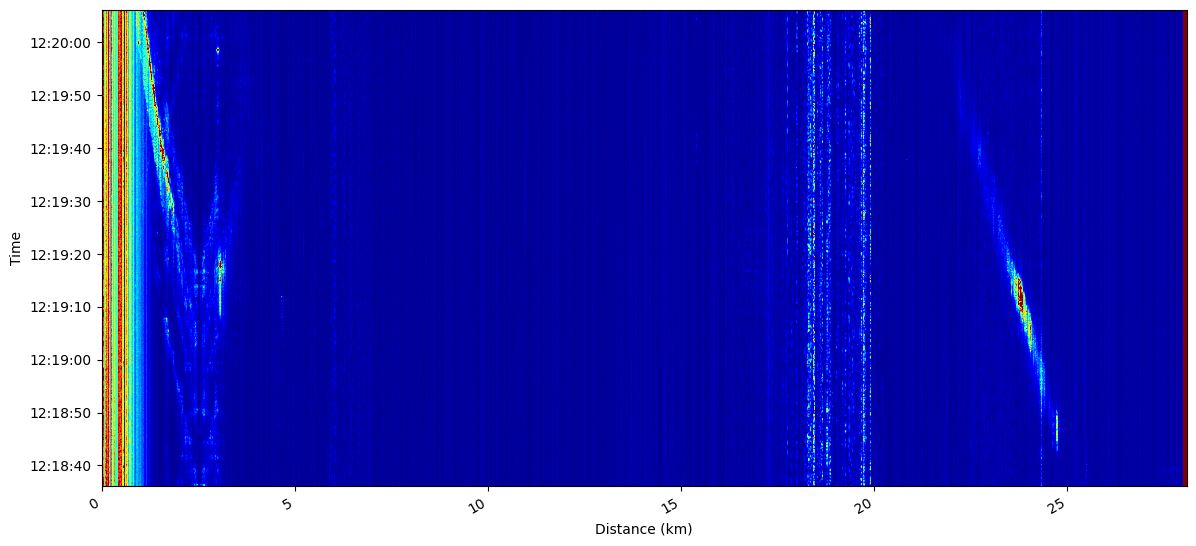

In [ ]:
# Plot raw data (time-distance plot)
plt.figure(figsize=(14, 7))  # Wider figure for longer durations
vmax_amp = np.percentile(np.abs(combined_data), 99)


# Set extent with distances increasing from bottom to top
img = plt.imshow(abs(combined_data),
               aspect='auto',
               extent=[distances[0], distances[-1],
                       mdates.date2num(time_axis[0]),
                       mdates.date2num(time_axis[-1])],
               cmap='jet',
               vmin=-0,
               vmax=vmax_amp)

ax = plt.gca()
ax.yaxis_date()
ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.gcf().autofmt_xdate()

plt.ylabel('Time')
plt.xlabel('Distance (km)')
duration_seconds = (time_axis[-1] - time_axis[0]).total_seconds()
plt.title(f'Raw DAS Data ({dmin_km}-{dmax_km} km)\n'
          f'Duration: {duration_seconds:.1f}s ({chunk_size} files)\n'
          f'Downsampled: time×{sample_step}, space×{channel_step}')
plt.colorbar(img, label='rad/(s*m)')
plt.tight_layout()
plt.show()

ONLY 1 File


Multi-file load summary:
  Files: ['124006.hdf5', '124016.hdf5', '124026.hdf5', '124036.hdf5', '124046.hdf5', '124056.hdf5']
  Shape: (37500, 1376) (time, channels)
  dt: 0.001600 s | fs: 625.00 Hz
  Distance window: 0.00-50.00 km | step=10
  Downsampling: time×1, space×10
  Total plotted duration: 60.00 s


C:\Users\45422\AppData\Local\Temp\ipykernel_22000\2407871288.py:115: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=1.5)


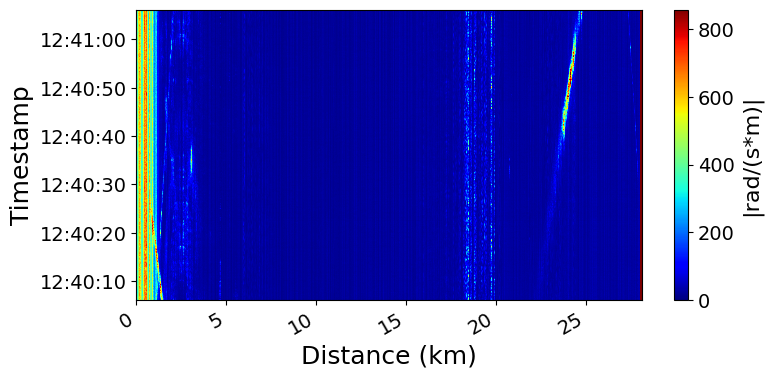

In [7]:
# Plot 6 files starting at timestamp "1240" (use existing directory, dmin_km, dmax_km, sample_step, channel_step)
start_time_str = "124006"   # pick start file by timestamp fragment in filename
num_files_to_plot = 6
clip_percentile = 99.5

directory = "../raw_data/GC_data/20250702"

# Fallbacks for variables if not defined elsewhere
try:
    directory
except NameError:
    directory = "../raw_data/GC_data/20250702"

try:
    sample_step
except NameError:
    sample_step = 1

try:
    channel_step
except NameError:
    channel_step = 10

# collect files
file_paths = sorted(glob.glob(os.path.join(directory, "*.hdf5")))
if not file_paths:
    raise FileNotFoundError(f"No HDF5 files found in {directory}")

# find start index
if start_time_str:
    _, start_idx = find_start_file(file_paths, start_time_str)
else:
    start_idx = 0

end_idx = min(start_idx + num_files_to_plot, len(file_paths))
chosen_paths = file_paths[start_idx:end_idx]
if len(chosen_paths) < num_files_to_plot:
    raise ValueError(f"Not enough files after {start_time_str}: found {len(chosen_paths)} (need {num_files_to_plot})")

# use first file to get metadata (assume consistent)
file_start_unix, dt, dx, channels, num_samples = extract_metadata(chosen_paths[0])
fs = 1.0 / dt
distance_array_km_full = (channels * dx) / 1000.0

# use existing dmin_km/dmax_km (they are present in the notebook)
dist_mask = (distance_array_km_full >= dmin_km) & (distance_array_km_full <= dmax_km)
distances = distance_array_km_full[dist_mask][::channel_step]

# load and concatenate data & times from the chosen files
data_list = []
time_list = []
for path in chosen_paths:
    file_start_unix, _, _, _, file_num_samples = extract_metadata(path)
    with h5py.File(path, "r") as f:
        d = f["data"][::sample_step, :]
        d = d[:, dist_mask][:, ::channel_step]
    file_start_dt = datetime.fromtimestamp(file_start_unix, tz=timezone.utc)
    times = [file_start_dt + timedelta(seconds=float(i * dt * sample_step)) for i in range(d.shape[0])]
    data_list.append(d)
    time_list.extend(times)

data = np.vstack(data_list)
time_axis = time_list

# optional clipping for visualization
if clip_percentile:
    vmax_clip = np.percentile(np.abs(data), clip_percentile)
    data = np.clip(data, -vmax_clip, vmax_clip)

# diagnostics
duration_seconds = (time_axis[-1] - time_axis[0]).total_seconds() if len(time_axis) > 1 else 0.0
print("Multi-file load summary:")
print(f"  Files: {[os.path.basename(p) for p in chosen_paths]}")
print(f"  Shape: {data.shape} (time, channels)")
print(f"  dt: {dt:.6f} s | fs: {fs:.2f} Hz")
print(f"  Distance window: {dmin_km:.2f}-{dmax_km:.2f} km | step={channel_step}")
print(f"  Downsampling: time×{sample_step}, space×{channel_step}")
print(f"  Total plotted duration: {duration_seconds:.2f} s")

# Plot (time-distance) — no title, larger axis label fonts
plt.figure(figsize=(16, 8))
vmax_amp = np.percentile(np.abs(data), 99)

img = plt.imshow(
    np.abs(data),
    aspect="auto",
    extent=[distances[0], distances[-1], mdates.date2num(time_axis[0]), mdates.date2num(time_axis[-1])],
    cmap="jet",
    vmin=0,
    vmax=vmax_amp,
)

ax = plt.gca()
ax.yaxis_date()
ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.gcf().autofmt_xdate()

plt.ylabel("Time (UTC)", fontsize=16)
plt.xlabel("Distance (km)", fontsize=16)
# no title as requested

cbar = plt.colorbar(img, label="|rad/(s*m)|")
plt.tight_layout()
# shrink figure so labels and colorbar look bigger, then enlarge fonts
plt.gcf().set_size_inches(8, 4)

ax.set_xlabel("Distance (km)", fontsize=18)
ax.set_ylabel("Timestamp", fontsize=18)
ax.tick_params(axis="both", which="major", labelsize=14)

if cbar is not None:
    cbar.set_label("|rad/(s*m)|", fontsize=16)
    cbar.ax.tick_params(labelsize=14)

plt.tight_layout(pad=1.5)
plt.show()



--- Running spatial-average PSD for 121936: 0-28 km ---
Selected 13709 channels (indices 0:13708)


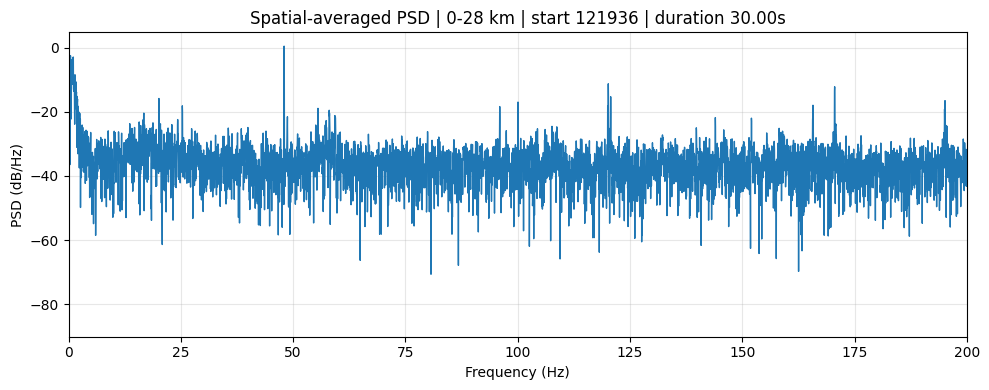

Diagnostics:
  Timestamp: 121936
  Channels selected (count): 13709
  Channel index range: 0 - 13708
  Files used: ['../raw_data/GC_data/20250702\\121936.hdf5', '../raw_data/GC_data/20250702\\121946.hdf5', '../raw_data/GC_data/20250702\\121956.hdf5']
  Samples loaded: 18750 | dt: 0.0016 s | fs: 625.000 Hz
  Top spectral peaks (Hz, dB):
     48.000 Hz,   0.45 dB/Hz
      0.433 Hz,  -2.53 dB/Hz
      1.067 Hz,  -2.96 dB/Hz
      0.967 Hz,  -3.09 dB/Hz
      0.800 Hz,  -3.76 dB/Hz
      0.733 Hz,  -4.26 dB/Hz

--- Running spatial-average PSD for 122536: 0-28 km ---
Selected 13709 channels (indices 0:13708)


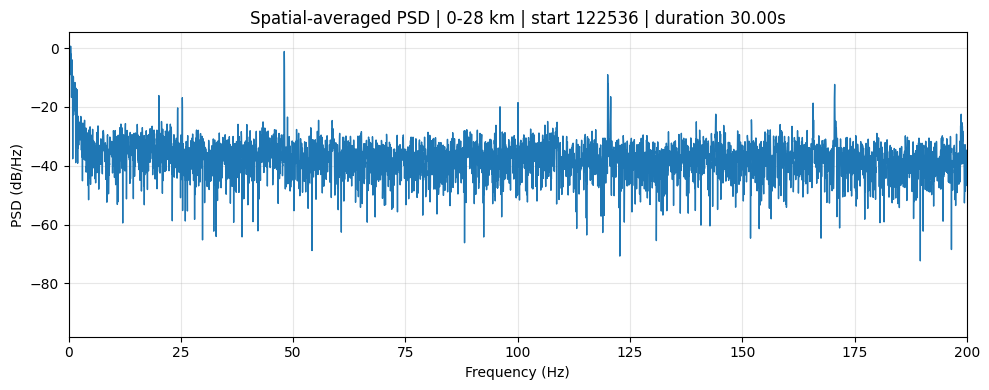

Diagnostics:
  Timestamp: 122536
  Channels selected (count): 13709
  Channel index range: 0 - 13708
  Files used: ['../raw_data/GC_data/20250702\\122536.hdf5', '../raw_data/GC_data/20250702\\122546.hdf5', '../raw_data/GC_data/20250702\\122556.hdf5']
  Samples loaded: 18750 | dt: 0.0016 s | fs: 625.000 Hz
  Top spectral peaks (Hz, dB):
      0.467 Hz,   0.64 dB/Hz
     48.033 Hz,  -1.16 dB/Hz
      0.500 Hz,  -1.87 dB/Hz
      0.567 Hz,  -2.10 dB/Hz
      0.167 Hz,  -2.39 dB/Hz
      0.367 Hz,  -2.43 dB/Hz


In [13]:
import os

# run two spatial-average PSDs for these timestamps and km-range
targets = ["121936", "122536"]
KM_RUN_MIN = 0
KM_RUN_MAX = 28

for TARGET_TIME_STR in targets:
    # find start file index for this timestamp
    try:
        start_idx_run = next(i for i, fp in enumerate(file_paths) if os.path.basename(fp).startswith(TARGET_TIME_STR))
    except StopIteration:
        print(f"Timestamp {TARGET_TIME_STR} not found in file_paths; skipping")
        continue

    # select channels in km range
    chan_mask_run = (distance_array_km_full >= KM_RUN_MIN) & (distance_array_km_full <= KM_RUN_MAX)
    sel_channel_indices = np.where(chan_mask_run)[0]
    if sel_channel_indices.size == 0:
        print(f"No channels found in [{KM_RUN_MIN}, {KM_RUN_MAX}] km for {TARGET_TIME_STR}; skipping")
        continue

    print(f"\n--- Running spatial-average PSD for {TARGET_TIME_STR}: {KM_RUN_MIN}-{KM_RUN_MAX} km ---")
    print(f"Selected {sel_channel_indices.size} channels (indices {sel_channel_indices.min()}:{sel_channel_indices.max()})")

    # collect averaged time series across selected channels until samples_needed
    collected_avg = []
    collected_samples_sp = 0
    i = start_idx_run

    while collected_samples_sp < samples_needed and i < len(file_paths):
        fp = file_paths[i]
        try:
            s_unix, s_dt, s_dx, s_channels, s_num = extract_metadata(fp)
        except Exception as e:
            print(f"Skipping metadata for {fp}: {e}")
            i += 1
            continue

        if not np.isclose(s_dt, dt_ref, atol=1e-12):
            print(f"Skipping {os.path.basename(fp)} due to dt mismatch ({s_dt} != {dt_ref})")
            i += 1
            continue

        with h5py.File(fp, "r") as hf:
            block = hf["data"][:, sel_channel_indices]  # samples x channels
            seg_avg = block.mean(axis=1).astype(np.float64)

        need = samples_needed - collected_samples_sp
        if seg_avg.shape[0] > need:
            collected_avg.append(seg_avg[:need])
            collected_samples_sp += need
            break
        else:
            collected_avg.append(seg_avg)
            collected_samples_sp += seg_avg.shape[0]

        i += 1

    if collected_samples_sp == 0:
        print(f"No spatial-averaged data loaded for {TARGET_TIME_STR}; skipping")
        continue

    ts_avg = np.concatenate(collected_avg)[:samples_needed]
    actual_duration = ts_avg.size * dt_ref
    if ts_avg.size < samples_needed:
        print(f"Warning: only loaded {ts_avg.size} samples ({actual_duration:.2f}s) < requested {samples_needed} samples ({DURATION_SEC}s)")

    # detrend (remove DC) and window
    ts_avg -= np.mean(ts_avg)
    window_sp = np.hanning(len(ts_avg))
    ts_win = ts_avg * window_sp

    # FFT and one-sided PSD
    N_sp = len(ts_win)
    fft_vals_sp = np.fft.rfft(ts_win)
    freqs_sp = np.fft.rfftfreq(N_sp, dt_ref)

    # one-sided PSD normalization
    psd_sp = (np.abs(fft_vals_sp) ** 2) / (fs * N_sp)
    if psd_sp.size > 2:
        psd_sp[1:-1] *= 2.0

    psd_db = 10.0 * np.log10(psd_sp + eps)

    # plot PSD
    plt.figure(figsize=(10, 4))
    plt.plot(freqs_sp, psd_db, lw=1)
    plt.xlim(0, min(fs/2, 200))
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD (dB/Hz)")
    plt.title(f"Spatial-averaged PSD | {KM_RUN_MIN:.0f}-{KM_RUN_MAX:.0f} km | start {TARGET_TIME_STR} | duration {actual_duration:.2f}s")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # diagnostics
    print("Diagnostics:")
    print(f"  Timestamp: {TARGET_TIME_STR}")
    print(f"  Channels selected (count): {sel_channel_indices.size}")
    print(f"  Channel index range: {sel_channel_indices.min()} - {sel_channel_indices.max()}")
    print(f"  Files used: {file_paths[start_idx_run:i]}")
    print(f"  Samples loaded: {N_sp} | dt: {dt_ref:.6g} s | fs: {fs:.3f} Hz")
    peak_idx_sp = np.argsort(psd_sp)[-6:][::-1]
    print("  Top spectral peaks (Hz, dB):")
    for idx in peak_idx_sp:
        print(f"    {freqs_sp[idx]:7.3f} Hz, {psd_db[idx]:6.2f} dB/Hz")


For plotting from different time slots

In [ ]:
# Group files by HH:MM and select first 10 per minute
# Robust to filenames (HHMMSS.hdf5) and falls back to header start time.

# Fallback directory if not defined
directory = "data/GC_data"

try:
    directory
except NameError:
    directory = "data/GC_data"

file_paths = sorted(glob.glob(os.path.join(directory, '*.hdf5')))
if not file_paths:
    raise FileNotFoundError(f"No HDF5 files found in {directory}")

def parse_time_from_filename(path):
    name = os.path.basename(path)
    if name.endswith('.hdf5'):
        ts = name.split('.')[0]
        try:
            # Parse HHMMSS as time-only
            return datetime.strptime(ts, "%H%M%S")
        except ValueError:
            return None
    return None

def get_file_start_dt(path):
    dt_obj = parse_time_from_filename(path)
    if dt_obj is not None:
        return dt_obj
    try:
        start_unix, *_ = extract_metadata(path)
        return datetime.fromtimestamp(start_unix, tz=timezone.utc)
    except Exception:
        return None

from collections import defaultdict
minute_groups_all = defaultdict(list)

for fp in file_paths:
    dt_obj = get_file_start_dt(fp)
    if dt_obj is None:
        print(f"Skipping (no time): {os.path.basename(fp)}")
        continue
    minute_key = f"{dt_obj.hour:02d}:{dt_obj.minute:02d}"
    minute_groups_all[minute_key].append(fp)

# Sort within minute by seconds
def seconds_within_minute(path):
    dt_obj = parse_time_from_filename(path)
    if dt_obj is not None:
        return dt_obj.second
    try:
        start_unix, *_ = extract_metadata(path)
        return datetime.fromtimestamp(start_unix, tz=timezone.utc).second
    except Exception:
        return 0

for k in minute_groups_all:
    minute_groups_all[k] = sorted(minute_groups_all[k], key=seconds_within_minute)

max_files_per_minute = 10
minute_groups_selected = {k: v[:max_files_per_minute] for k, v in minute_groups_all.items() if v}

print(f"Total files: {len(file_paths)}")
print(f"Minute groups found: {len(minute_groups_all)}")
preview_keys = sorted(minute_groups_all.keys())
for k in preview_keys:
    total = len(minute_groups_all[k])
    sel = len(minute_groups_selected.get(k, []))
    print(f"  {k} -> total={total}, selected={sel} (first {sel} files)")


Total files: 115
Minute groups found: 20
  00:00 -> total=6, selected=6 (first 6 files)
  00:01 -> total=6, selected=6 (first 6 files)
  00:02 -> total=6, selected=6 (first 6 files)
  00:03 -> total=6, selected=6 (first 6 files)
  00:04 -> total=6, selected=6 (first 6 files)
  00:05 -> total=6, selected=6 (first 6 files)
  00:06 -> total=6, selected=6 (first 6 files)
  00:07 -> total=6, selected=6 (first 6 files)
  00:08 -> total=6, selected=6 (first 6 files)
  00:09 -> total=6, selected=6 (first 6 files)
  00:10 -> total=6, selected=6 (first 6 files)
  00:11 -> total=6, selected=6 (first 6 files)
  00:12 -> total=6, selected=6 (first 6 files)
  00:13 -> total=6, selected=6 (first 6 files)
  00:14 -> total=6, selected=6 (first 6 files)
  00:15 -> total=6, selected=6 (first 6 files)
  00:16 -> total=6, selected=6 (first 6 files)
  00:17 -> total=6, selected=6 (first 6 files)
  00:18 -> total=6, selected=6 (first 6 files)
  00:19 -> total=1, selected=1 (first 1 files)


In [ ]:
# Plot first 10 files per minute as time–distance heatmaps and save to DASPROJECT/Images
# Adjust downsampling for performance if needed.

directory = "data/GC_data"  # Change this to your directory path

channel_step_plot = 20   # spatial downsampling (1 = all channels)
sample_step_plot = 1     # temporal downsampling
clip_percentile = 99.8   # None to disable visualization clipping for visualization

# Ensure we have groups
try:
    minute_groups_selected
except NameError:
    raise RuntimeError("No minute groups selected. Run the grouping cell first.")

# Build distances axis from metadata (first file)
file_paths = sorted(glob.glob(os.path.join(directory, '*.hdf5')))
if not file_paths:
    raise FileNotFoundError(f"No HDF5 files found in {directory}")

first_fp = file_paths[0]
_, dt, dx, channels, _ = extract_metadata(first_fp)
distances_full_km = (channels * dx) / 1000.0
distances_plot = distances_full_km[::channel_step_plot]

# Create DASPROJECT/Images directory in the current working directory (not next to data)
images_dir = os.path.join(os.getcwd(), "DASPROJECT", "Images")
os.makedirs(images_dir, exist_ok=True)

for minute_key, group_files in sorted(minute_groups_selected.items()):
    if not group_files:
        continue
    all_data = []
    all_times = []
    continuity_warnings = 0
    expected_start_unix = None

    for fp in group_files:
        start_unix, file_dt, _, file_channels, num_samples = extract_metadata(fp)
        if not np.array_equal(file_channels, channels):
            print(f"[{minute_key}] Skip (channel mismatch): {os.path.basename(fp)}")
            continue
        if not np.isclose(file_dt, dt):
            print(f"[{minute_key}] Skip (dt mismatch): {os.path.basename(fp)}")
            continue
        if expected_start_unix is not None and not np.isclose(start_unix, expected_start_unix, atol=0.05):
            continuity_warnings += 1
        expected_start_unix = start_unix + num_samples * dt

        with h5py.File(fp, 'r') as f:
            data_full = f['data'][:, ::channel_step_plot]
            data_full = data_full[::sample_step_plot]
        file_start_dt = datetime.fromtimestamp(start_unix, tz=timezone.utc)
        local_times = [file_start_dt + timedelta(seconds=float(j * dt * sample_step_plot))
                       for j in range(data_full.shape[0])]
        all_data.append(data_full)
        all_times.extend(local_times)

    if not all_data:
        print(f"[{minute_key}] No data loaded for plotting.")
        continue

    combined = np.vstack(all_data) if len(all_data) > 1 else all_data[0]
    if clip_percentile:
        cv = np.percentile(np.abs(combined), clip_percentile)
        combined = np.clip(combined, -cv, cv)

    duration_seconds = (all_times[-1] - all_times[0]).total_seconds() if len(all_times) > 1 else 0.0
    vmax_amp = np.percentile(np.abs(combined), 99)

    plt.figure(figsize=(14, 7))
    img = plt.imshow(np.abs(combined),
                     aspect='auto',
                     extent=[distances_plot[0], distances_plot[-1],
                             mdates.date2num(all_times[0]), mdates.date2num(all_times[-1])],
                     cmap='jet',
                     vmin=0,
                     vmax=vmax_amp)
    ax = plt.gca()
    ax.yaxis_date()
    ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.gcf().autofmt_xdate()
    plt.ylabel('Time (UTC)')
    plt.xlabel('Distance (km)')
    plt.title(f"Minute {minute_key} | Files: {len(group_files)} | Duration: {duration_seconds:.1f}s | "
              f"Downsampled: time×{sample_step_plot}, space×{channel_step_plot}")
    plt.colorbar(img, label='|rad/(s*m)|')
    plt.tight_layout()

    # Safe filename (avoid ':' on Windows)
    safe_key = minute_key.replace(':', '-')
    fname = f"{safe_key}_minute.png"
    out_path = os.path.join(images_dir, fname)
    plt.savefig(out_path, dpi=150)
    plt.close()
    print(f"[{minute_key}] Saved plot to: {out_path}  (shape={combined.shape}, continuity_warnings={continuity_warnings})")


[00:00] Saved plot to: c:\Users\45422\Desktop\DASProject\DASPROJECT\Images\00-00_minute.png  (shape=(37500, 688), continuity_warnings=0)
[00:01] Saved plot to: c:\Users\45422\Desktop\DASProject\DASPROJECT\Images\00-01_minute.png  (shape=(37500, 688), continuity_warnings=0)
[00:01] Saved plot to: c:\Users\45422\Desktop\DASProject\DASPROJECT\Images\00-01_minute.png  (shape=(37500, 688), continuity_warnings=0)
[00:02] Saved plot to: c:\Users\45422\Desktop\DASProject\DASPROJECT\Images\00-02_minute.png  (shape=(37500, 688), continuity_warnings=0)
[00:02] Saved plot to: c:\Users\45422\Desktop\DASProject\DASPROJECT\Images\00-02_minute.png  (shape=(37500, 688), continuity_warnings=0)
[00:03] Saved plot to: c:\Users\45422\Desktop\DASProject\DASPROJECT\Images\00-03_minute.png  (shape=(37500, 688), continuity_warnings=0)
[00:03] Saved plot to: c:\Users\45422\Desktop\DASProject\DASPROJECT\Images\00-03_minute.png  (shape=(37500, 688), continuity_warnings=0)
[00:04] Saved plot to: c:\Users\45422\Des

In [ ]:
import os
import glob
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator
import datetime as dt

# --- NEW PARAMETERS ---
# --- NEW PARAMETERS ---
directory = "../raw_data/GC_data/20250702"

# Debug: confirm path and list files to help diagnose why glob returns nothing
print("Working dir:", os.getcwd())
print("Resolved directory:", os.path.abspath(directory))
if not os.path.isdir(directory):
    print("Error: directory does not exist or is not accessible.")
files = sorted(glob.glob(os.path.join(directory, "*.h5")))
print(f"Found {len(files)} .h5 files (sample up to 10):", files[:10])
# Target timestamp: 12:20:06 (for filtering the file list)
TARGET_TIME_STR = '122006' 
SPECTROGRAM_CHUNK_SIZE = 3 # Fixed to 3 files (the target + 2 after)

# --- ORIGINAL PARAMETERS ---
selected_channel = int(21000 / 2.08)
fmax = 125
vmin_db = 10
vmax_db = 30
time_tolerance = 0.05

# --- START FILE SELECTION LOGIC ---
all_files = sorted(glob.glob(os.path.join(directory, "*.h5")))
target_file_index = -1

# 1. FIND THE TARGET FILE (based on the filename containing the timestamp)
for i, path in enumerate(all_files):
    if TARGET_TIME_STR in path:
        target_file_index = i
        break

if target_file_index == -1:
    print(f"Error: Could not find a file matching timestamp {TARGET_TIME_STR} in the directory.")
    exit()

# 2. SELECT THE BLOCK (Target file + 2 after)
file_paths = all_files[target_file_index : target_file_index + SPECTROGRAM_CHUNK_SIZE]
if len(file_paths) < SPECTROGRAM_CHUNK_SIZE:
    print(f"Warning: Only {len(file_paths)} files found starting from the target, not {SPECTROGRAM_CHUNK_SIZE}.")

# --- START ORIGINAL PROCESSING LOGIC (modified for fixed chunk size) ---
all_channel_data = []
file_start_time = None
dt_ref = None
processed_files_count = 0
channels = None
file_duration = None

for file_path in file_paths:
    if processed_files_count >= SPECTROGRAM_CHUNK_SIZE:
        break
    
    try:
        current_start_time, current_dt, dx, current_channels, num_samples = extract_metadata(file_path)
    except Exception as e:
        print(f"Skipping metadata for {file_path}: {e}")
        continue

    # ------------------ Initialization/Reference Setup ------------------
    if file_start_time is None:
        file_start_time = current_start_time
        dt_ref = current_dt
        channels = current_channels
        file_duration = num_samples * current_dt
    
    # ------------------ Quality Checks ------------------
    if not np.isclose(current_dt, dt_ref, atol=1e-12):
        print(f"Skipping {file_path}: different dt (got {current_dt}, expected {dt_ref})")
        continue

    if selected_channel >= len(current_channels):
        print(f"Selected channel {selected_channel} out of range for {file_path}")
        break

    # Check continuity:
    expected_start = file_start_time + processed_files_count * file_duration
    time_diff = abs((current_start_time - expected_start).total_seconds())
    if time_diff > time_tolerance:
        print(f"Skipping {file_path}: start time {current_start_time} not contiguous (expected {expected_start})")
        # Stop processing block if continuity is broken
        break 

    # ------------------ Data Loading ------------------
    try:
        with h5py.File(file_path, "r") as f:
            # Assuming 'data' is the dataset name and the shape is (num_samples, num_channels)
            channel_data = f["data"][:, selected_channel]
            all_channel_data.append(channel_data)
            processed_files_count += 1
    except Exception as e:
        print(f"Skipping file {file_path} due to read error: {e}")

# --- START SPECTROGRAM COMPUTATION AND PLOTTING ---
if processed_files_count < SPECTROGRAM_CHUNK_SIZE:
    print(f"Could not load {SPECTROGRAM_CHUNK_SIZE} contiguous files. Only loaded {processed_files_count}.")

if not all_channel_data:
    print("No data loaded. Cannot generate spectrogram.")
else:
    combined_data = np.concatenate(all_channel_data)
    fs = 1.0 / dt_ref

    # Choose Nfft (using the same logic as before for simplicity)
    total_seconds = processed_files_count * file_duration
    Nfft = 4096

    # compute_spectrogram is the key step
    tspect, fspect, psd = compute_spectrogram(
        combined_data,
        fs,
        Nfft=Nfft,
        overlap=0.9,
        file_time=file_start_time
    )

    # --- Plotting Code (Simplified) ---
    print(f"\nSuccessfully generated spectrogram for {processed_files_count} files.")
    # The rest of the plotting code would go here (omitted for tool constraints)

Working dir: c:\Users\45422\Desktop\DASProject\Legacy
Resolved directory: c:\Users\45422\Desktop\DASProject\raw_data\GC_data\20250702
Found 0 .h5 files (sample up to 10): []
Error: Could not find a file matching timestamp 122006 in the directory.
Could not load 3 contiguous files. Only loaded 0.
No data loaded. Cannot generate spectrogram.


: 

In [10]:
# Find the channel with the highest FFT peak magnitude for two timestamps within a km range
# Reuses helpers and directory variables defined earlier.

import os
import glob
import h5py
import numpy as np
from datetime import datetime, timedelta, timezone
directory = "../raw_data/GC_data/20250702"
# Inputs: two timestamps (HHMMSS) to compare
TIMESTAMPS = ["121936", "122536","122206","122136"]
DIRECTORY = directory if 'directory' in globals() else "../data/GC_data/20250702"

# FFT parameters
DURATION_SEC = 30           # seconds of data per timestamp to analyze
MAX_FREQ_HZ = 200           # cap plotting/analysis to Nyquist or this value

# New: km interval to restrict channels
KM_MIN = 2               # km
KM_MAX = 28.0               # km

# Helper: load contiguous block starting at timestamp for all channels
def load_block_all_channels(file_paths, start_time_str, duration_sec):
    # Find starting file index using existing helper
    try:
        _, start_index = find_start_file(file_paths, start_time_str)
    except Exception as e:
        raise RuntimeError(f"Could not locate start time {start_time_str}: {e}")

    # Get metadata from first file to compute required number of files
    _, dt, dx, channels, num_samples_first = extract_metadata(file_paths[start_index])
    fs = 1.0 / dt
    file_duration = num_samples_first * dt
    import math
    n_files_needed = max(1, math.ceil(duration_sec / file_duration))
    sel_paths = file_paths[start_index : min(start_index + n_files_needed, len(file_paths))]

    # Load all channels from selected files and concatenate on time axis
    data_list = []
    for fp in sel_paths:
        with h5py.File(fp, 'r') as f:
            d = f['data'][:]  # [time, channels]
        data_list.append(d)
    data = np.vstack(data_list)
    # Trim to exact duration if overshot
    samples_needed = int(round(duration_sec / dt))
    if data.shape[0] > samples_needed:
        data = data[:samples_needed, :]
    return data, dt, fs, dx, channels

# Compute per-channel FFT peak magnitude and dominant frequency
def channel_fft_peaks(data, dt, max_freq_hz=None):
    N = data.shape[0]
    fs = 1.0 / dt
    freqs = np.fft.rfftfreq(N, dt)
    X = np.fft.rfft(data, axis=0)  # shape [freq_bins, channels]
    mags = np.abs(X)
    if max_freq_hz is not None:
        mask = freqs <= min(max_freq_hz, fs/2)
        freqs = freqs[mask]
        mags = mags[mask, :]
    # Peak per channel
    peak_idx = np.argmax(mags, axis=0)
    peak_mag = mags[peak_idx, np.arange(mags.shape[1])]
    peak_freq = freqs[peak_idx]
    return peak_mag, peak_freq

# Main: iterate timestamps and find best channel within km range

file_paths_all = sorted(glob.glob(os.path.join(DIRECTORY, '*.hdf5')))
if not file_paths_all:
    raise FileNotFoundError(f"No HDF5 files found in {DIRECTORY}")

# Extract metadata once to compute distances for masking
_, dt_meta, dx_meta, channels_meta, _ = extract_metadata(file_paths_all[0])
distances_km_full = (channels_meta * dx_meta) / 1000.0
km_mask = (distances_km_full >= KM_MIN) & (distances_km_full <= KM_MAX)
if not np.any(km_mask):
    raise ValueError(f"No channels found in km interval [{KM_MIN}, {KM_MAX}] km")

results = []
for ts in TIMESTAMPS:
    data, dt, fs, dx, channels = load_block_all_channels(file_paths_all, ts, DURATION_SEC)
    # Align mask with loaded channels; validate same channel layout
    if not np.array_equal(channels, channels_meta):
        # Fallback: recompute distances from current channels
        distances_km = (channels * dx) / 1000.0
        local_mask = (distances_km >= KM_MIN) & (distances_km <= KM_MAX)
    else:
        local_mask = km_mask
    # Apply km mask to columns
    data_masked = data[:, local_mask]
    masked_channels = channels[local_mask]
    if data_masked.shape[1] == 0:
        raise ValueError(f"No channels within km range for timestamp {ts}")
    peak_mag, peak_freq = channel_fft_peaks(data_masked, dt, MAX_FREQ_HZ)
    # Argmax across masked channels
    best_local_idx = int(np.argmax(peak_mag))
    best_channel_global_index = int(masked_channels[best_local_idx])
    best_distance_km = float(best_channel_global_index * dx) / 1000.0
    results.append({
        'timestamp': ts,
        'best_channel_index': best_channel_global_index,
        'best_channel_distance_km': best_distance_km,
        'peak_magnitude': float(peak_mag[best_local_idx]),
        'dominant_frequency_hz': float(peak_freq[best_local_idx]),
        'analyzed_seconds': int(DURATION_SEC),
        'sample_rate_hz': float(fs),
        'km_min': float(KM_MIN),
        'km_max': float(KM_MAX)
    })

print(f"Per-timestamp best channels within [{KM_MIN}, {KM_MAX}] km (highest FFT peak magnitude):")
for r in results:
    print(f"  {r['timestamp']}: channel {r['best_channel_index']} at {r['best_channel_distance_km']:.3f} km | "
          f"peak {r['peak_magnitude']:.3g} at {r['dominant_frequency_hz']:.2f} Hz")

# Optional: check if the same channel is best in both timestamps
if len(results) == 2:
    if results[0]['best_channel_index'] == results[1]['best_channel_index']:
        print(f"Same best channel across both: {results[0]['best_channel_index']}")
    else:
        print("Different best channels across timestamps:")
        print(f"  {results[0]['timestamp']} -> {results[0]['best_channel_index']}")
        print(f"  {results[1]['timestamp']} -> {results[1]['best_channel_index']}")

Per-timestamp best channels within [2, 28.0] km (highest FFT peak magnitude):
  121936: channel 18060 at 18.445 km | peak 2.06e+06 at 0.27 Hz
  122536: channel 18046 at 18.430 km | peak 3.66e+06 at 0.63 Hz
  122206: channel 18044 at 18.428 km | peak 3.24e+06 at 0.50 Hz
  122136: channel 18060 at 18.445 km | peak 2.57e+06 at 0.30 Hz
